# Name entity recognition

In [64]:
import pandas as pd
import spacy
from spacy.tokens import Doc
nlp = spacy.load("fr_core_news_lg")
import re
import matplotlib.pyplot as plt

In [110]:
db = {}

corpus = [
    "text_1.txt",
    "text_2.txt"
]

for doc in corpus:
    db[doc] = {}
    db[doc]["Entities"] = {}

    with open("corpus_cleaned/"+doc, "r", encoding="utf-8") as file:
        text = file.read()

    # Create a Spacy doc
    spacy_doc = nlp(text)       

    # =================== NER ===================

    for ent in spacy_doc.ents:  
        if ent.label_ not in db[doc]["Entities"]:
            db[doc]["Entities"][f'{ent.label_}'] = []
        db[doc]["Entities"][f'{ent.label_}'].append(ent.text)

    # ============== Word detection ==============

    target_words_og = ['écologique', 'Océan', 'Occitanie']
    target_words = [element.lower() for element in target_words_og]

    # Create a dictionary to count occurrences
    word_count = {word: 0 for word in target_words}


    # Tokenize the text and check for specific words
    for token in spacy_doc:
        if not token.is_punct:  # Exclude punctuation
            if token.lemma_.lower() in word_count:  # Check if the word is in our list
                word_count[token.lemma_.lower()] += 1

    db[doc]["Voc of interest"] = word_count

print(db)
# Now you can access the `doc` object to analyze the text
# For example, you can print the tokens
#for token in doc:
    #print(token.text, token.pos_, token.dep_)


{'text_1.txt': {'Entities': {'MISC': ['Risques Littoraux', 'Actions Positives de la Mairie'], 'LOC': ['Occitanie', 'Occitanie', 'Hérault', 'Pyrénées-Orientales', 'Palavas-les-Flots']}, 'Voc of interest': {'écologique': 2, 'océan': 0, 'occitanie': 2}}, 'text_2.txt': {'Entities': {'MISC': ['La Faune et la'], 'ORG': ['Flore Marine en Danger', 'Journal de la Mer et du Littoral'], 'LOC': ['Occitanie', 'Méditerranée'], 'PER': ['Pierre Delon', 'Delon']}, 'Voc of interest': {'écologique': 1, 'océan': 3, 'occitanie': 1}}}


In [102]:
test = "Occitanie Avec Pyrénées-Orientales océans écologie ET écologique"

doc2 = nlp(test)
for token in doc2:
    if not token.is_punct:  # Exclude punctuation
        print(f"{token.text} -> {token.lemma_}")  # Print word and its lemma

Occitanie -> Occitanie
Avec -> avec
Pyrénées -> Pyrénées
Orientales -> oriental
océans -> océan
écologie -> écologie
ET -> et
écologique -> écologique


In [105]:
le = ["AAod", "Ocedd"]
print(le[0].lower())



aaod


# domain name extraction

In [125]:
import re

def get_domain_names_from_list(list):
    
    pattern = r'https?://([^/]+)'           # Regular expression to extract the domain
    domain_count = {}                       # Dictionary to count the occurrences of each domain
    for url in urls:                        # Extract the domains and count them
        match = re.search(pattern, url)
        if match:
            domain = match.group(1)
            if domain in domain_count:
                domain_count[domain] += 1   # Increment count if domain already exists
            else:
                domain_count[domain] = 1    # Initialize count for new domain
    return domain_count

def get_domain_name(url):
    
    pattern = r'https?://([^/]+)'           # Regular expression to extract the domain
    match = re.search(pattern, url)
    if match:
        domain = match.group(1)
        return domain
    else:
        return 0

# Define your URLs
urls = [
    "https://www.lemonde.fr/planete/article/2024/10/18/inondations-et-crues-dix-departements-maintenus-en-vigilance-orange-plus-de-2-300-interventions-jeudi-annonce-le-gouvernement_6354878_3245.html",
    "https://fr.euronews.com/video/2024/07/15/no-comment-championnats-du-monde-de-kitesurf-et-de-wingsurf",
    "https://spacy.io/api/entityrecognizer#assigned-attributes",
    "https://spacy.io/api/entityrecognizer#assigned-attributes",
    "https://chatgpt.com/c/6712677f-30c0-8003-bfb7-74cc26860c10",
    "https://chatgpt.com/c/677f-30c0-8003-bfb7-860c10",
    "https://chatgpt.com/c/6712677f-30c0-8003-bfc26860c10",
    "https://gradschool.cornell.edu/admissions/prepare/personal-statements/",
    "https://adplist.org/",
    "https://www.qlik.com/us/bi/data-trends",
    "https://huggingface.co/tasks",
    "https://scienceetonnante.substack.com/p/grokking-les-modeles-dia-sont-ils",

]
l = get_domain_names_from_list(urls)
print(l)

{'www.lemonde.fr': 1, 'fr.euronews.com': 1, 'spacy.io': 2, 'chatgpt.com': 3, 'gradschool.cornell.edu': 1, 'adplist.org': 1, 'www.qlik.com': 1, 'huggingface.co': 1, 'scienceetonnante.substack.com': 1}


In [126]:
get_domain_name("https://jsonformatter.curiousconcept.com/#")

'jsonformatter.curiousconcept.com'

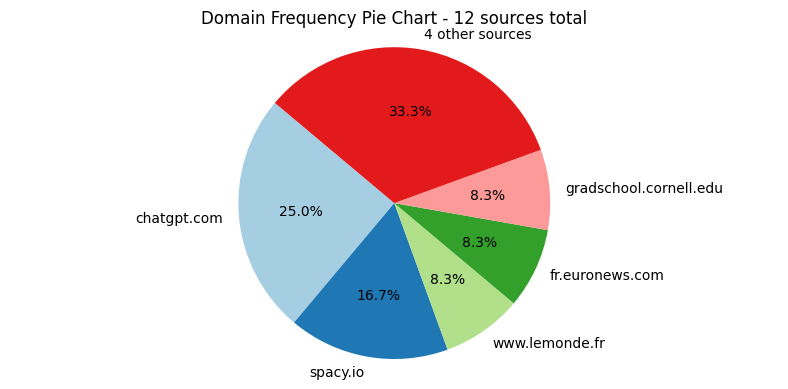

In [123]:
def plot_sources_distribution(domain_dict, visibility_thresold = 5, pie_plot = True):
    nb_of_src = sum(domain_dict.values())
    # Sort domains by count and get the top 10
    sorted_domains = sorted(domain_dict.items(), key=lambda x: x[1], reverse=True)
    top_domains = sorted_domains[:visibility_thresold]

    # Prepare data for the histogram
    labels = [domain for domain, count in top_domains]
    counts = [count for domain, count in top_domains]

    if pie_plot:
        # Add 'Others' category
        others_count = sum(count for domain, count in sorted_domains[visibility_thresold:])  # Sum counts of remaining domains
        if others_count > 0:
            labels.append(f'{others_count} other sources')  # Updated to show count of others
            counts.append(others_count)
        # Create the pie chart
        plt.figure(figsize=(8, 4))
        plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
        plt.title(f'Domain Frequency Pie Chart - {nb_of_src} sources total')
        plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
    else:
        # Create the histogram
        plt.figure(figsize=(10, 6))
        plt.barh(labels, counts, color='skyblue')
        plt.title('Domain Frequency')
        plt.xlabel('Frequency')
        plt.ylabel('Domains')
        plt.grid(axis='x')

    plt.tight_layout()
    plt.show()

plot_sources_distribution(l)